In [1]:
import pandas as pd

# Load raw file
file_path = "WISDM_ar_v1.1_raw.txt"

# Read and clean
data = []

with open(file_path, "r") as f:
    for line in f:
        line = line.strip().replace(";", "")
        parts = line.split(",")

        if len(parts) == 6:
            data.append(parts)

# Create DataFrame
df = pd.DataFrame(data, columns=[
    "user", "activity", "timestamp", "x", "y", "z"
])

# Convert types
df["x"] = pd.to_numeric(df["x"], errors="coerce")
df["y"] = pd.to_numeric(df["y"], errors="coerce")
df["z"] = pd.to_numeric(df["z"], errors="coerce")

# Drop missing values
df = df.dropna()

print(df.head())
print("Shape:", df.shape)

  user activity       timestamp         x          y         z
0   33  Jogging  49105962326000 -0.694638  12.680544  0.503953
1   33  Jogging  49106062271000  5.012288  11.264028  0.953424
2   33  Jogging  49106112167000  4.903325  10.882658 -0.081722
3   33  Jogging  49106222305000 -0.612916  18.496431  3.023717
4   33  Jogging  49106332290000 -1.184970  12.108489  7.205164
Shape: (1086465, 6)


In [2]:
print(df["activity"].unique())


['Jogging' 'Walking' 'Upstairs' 'Downstairs' 'Sitting' 'Standing']


In [3]:
df = df[df["activity"].isin(["Walking", "Jogging", "Sitting"])]

print(df["activity"].value_counts())

activity
Walking    418393
Jogging    336445
Sitting     59939
Name: count, dtype: int64


In [4]:
# Find minimum class count
min_count = df["activity"].value_counts().min()

# Balance dataset
df_balanced = df.groupby("activity").apply(lambda x: x.sample(min_count)).reset_index(drop=True)

print(df_balanced["activity"].value_counts())

activity
Jogging    59939
Sitting    59939
Walking    59939
Name: count, dtype: int64


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3500\2317827557.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_balanced = df.groupby("activity").apply(lambda x: x.sample(min_count)).reset_index(drop=True)


In [5]:
features = df_balanced[["x", "y", "z"]].values
labels = df_balanced["activity"].values

In [6]:
import numpy as np

def create_sequences(df, window_size=100, step=50):
    sequences = []
    labels = []

    # Group by user and activity
    grouped = df.groupby(["user", "activity"])

    for (user, activity), group in grouped:
        group = group.sort_values("timestamp")

        data = group[["x", "y", "z"]].values

        for i in range(0, len(data) - window_size, step):
            seq = data[i:i+window_size]
            sequences.append(seq)
            labels.append(activity)

    return np.array(sequences), np.array(labels)


X_seq, y_seq = create_sequences(df_balanced)

print("Sequence shape:", X_seq.shape)
print("Labels shape:", y_seq.shape)

Sequence shape: (3457, 100, 3)
Labels shape: (3457,)


In [7]:
# Add magnitude to each sequence
X_new = []

for seq in X_seq:
    mag = np.sqrt(seq[:, 0]**2 + seq[:, 1]**2 + seq[:, 2]**2)
    mag = mag.reshape(-1, 1)

    seq_new = np.hstack((seq, mag))
    X_new.append(seq_new)

X_new = np.array(X_new)

print("New shape:", X_new.shape)

New shape: (3457, 100, 4)


In [8]:
X_seq = X_new

In [9]:
activities = np.unique(y_seq)
print("Activities:", activities)

Activities: ['Jogging' 'Sitting' 'Walking']


In [10]:
from hmmlearn import hmm

models = {}

for activity in activities:
    # Select sequences of one activity
    sequences = X_seq[y_seq == activity]

    # Flatten sequences
    X = np.concatenate(sequences)
    lengths = [len(seq) for seq in sequences]

    # Create HMM
    model = hmm.GaussianHMM(
        n_components=5,        # hidden states
        covariance_type='diag',
        n_iter=100
    )

    # Train model
    model.fit(X, lengths)

    models[activity] = model

    print(f"✅ Trained HMM for {activity}")

✅ Trained HMM for Jogging
✅ Trained HMM for Sitting
✅ Trained HMM for Walking


In [11]:
def predict(models, sequence):
    scores = {}

    for activity, model in models.items():
        try:
            score = model.score(sequence)
            scores[activity] = score
        except:
            scores[activity] = float('-inf')

    # return activity with highest score
    return max(scores, key=scores.get)

In [12]:
y_pred = []

for seq in X_seq:
    pred = predict(models, seq)
    y_pred.append(pred)

y_pred = np.array(y_pred)

In [13]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_seq, y_pred))

print("\nClassification Report:")
print(classification_report(y_seq, y_pred))

Accuracy: 0.9702053803876193

Classification Report:
              precision    recall  f1-score   support

     Jogging       0.97      0.99      0.98      1151
     Sitting       1.00      0.95      0.97      1162
     Walking       0.94      0.97      0.96      1144

    accuracy                           0.97      3457
   macro avg       0.97      0.97      0.97      3457
weighted avg       0.97      0.97      0.97      3457



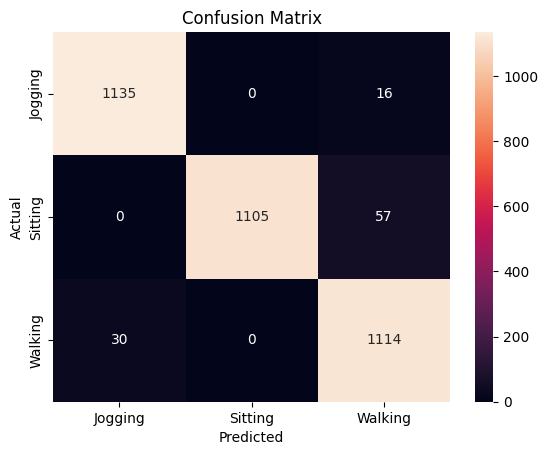

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_seq, y_pred, labels=activities)

sns.heatmap(cm, annot=True, fmt='d', xticklabels=activities, yticklabels=activities)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [15]:
import pickle

with open("hmm_models.pkl", "wb") as f:
    pickle.dump(models, f)

print("Models saved!")

Models saved!
